# Robustness Explanations -- Execution Time Analysis
This notebook provides a basic execution time analysis of robustness explanations, given synthetic QBAFs and their updates.

First, we install QBAF-Py and matplotlib:

In [ ]:
%%capture
!git clone https://github.com/TimKam/Quantitative-Bipolar-Argumentation
!pip install ./Quantitative-Bipolar-Argumentation
!pip install matplotlib

Next, we print out CPU information (out-comment accordingly, depending on MAC or LINUX):

In [1]:
!cat /proc/cpuinfo

cat: /proc/cpuinfo: No such file or directory


In [4]:
!sysctl -a | grep machdep.cpu

machdep.cpu.cores_per_package: 10
machdep.cpu.core_count: 10
machdep.cpu.logical_per_package: 10
machdep.cpu.thread_count: 10
machdep.cpu.brand_string: Apple M4


We import a few dependencies:

In [89]:
import math, random, time

import matplotlib.pyplot as plt
from statistics import mean, median

from qbaf import QBAFramework, QBAFARelations
from qbaf_generation.generation import *
from qbaf_visualizer.Visualizer import *
from qbaf_robustness.consistency_checks import *
from qbaf_robustness.inconsistency_checks import *
from qbaf_robustness.explanations import *

In [19]:
def generate_layered_qbaf(layers, connection_probability, semantics, min_strength=0, max_strength=1):
    args = []
    initial_strengths = []
    attacks = []
    supports = []
    args_by_layer = {}
    for index, layer in enumerate(layers):
        layer_args = []
        for i in range(0, layer):
            arg = f'a{index,i}'
            layer_args.append(arg)
            args.append(arg)
            initial_strengths.append(random.uniform(min_strength, max_strength))
            if not index == 0:
                for target_arg in args_by_layer[index-1]:
                    if random.random() < connection_probability:
                        if random.random() < 0.5:
                            attacks.append((arg, target_arg))
                        else:
                            supports.append((arg, target_arg))
        args_by_layer[index] = layer_args
            
    return QBAFramework(args, initial_strengths, attacks, supports, semantics=semantics)

In [67]:
def generate_layered_qbaf_chain(length, topics, max_layers, connection_probability, semantics, min_strength=0, max_strength=1):
    max_qbaf = generate_layered_qbaf(max_layers, connection_probability, semantics, min_strength, max_strength)
    max_args = max_qbaf.arguments
    qbafs = []
    args = topics
    initial_strengths = [max_qbaf.initial_strength(topic) for topic in topics]
    attacks = []
    supports = []
    remaining_args = [arg for arg in max_args if not arg in topics]
    random.shuffle(remaining_args)
    chunks = [remaining_args[i::length] for i in range(length)]
    for chunk in chunks:
        for arg in chunk:
            args.append(arg)
            initial_strengths.append(max_qbaf.initial_strength(arg))
            attacks.extend([(arg, target) for target in max_qbaf.attackedBy(arg) if target in args])
            attacks.extend([(source, arg) for source in max_qbaf.attackersOf(arg) if source in args])
            supports.extend([(arg, target) for target in max_qbaf.supportedBy(arg) if target in args])
            supports.extend([(source, arg) for source in max_qbaf.supportersOf(arg) if source in args])
        qbaf = QBAFramework(args, initial_strengths, attacks, supports, semantics=semantics)
        qbafs.append(qbaf)
    return qbafs

In [79]:
qbafs = generate_layered_qbaf_chain(4, ['a(0, 0)', 'a(0, 1)'], [2, 4, 4, 4], 0.5, "DFQuAD_model", min_strength=0.3, max_strength=0.7)

In [115]:
layers = [2, 8]
for _ in range(0, 18):
    layers.append(0)
n_arguments_list = []
# DFQuAD
robustness_times_dfquad = []
pocket_times_dfquad = []
# QE
robustness_times_qe = []
pocket_times_qe = []

for i in range(2, 20):
    for j in range(1, 21):
        layers[i] = j
        n_arguments_list.append(sum(layers))
        is_robust_dfquad_for_avg_times = []
        is_robust_qe_for_avg_times = []
        for _ in range(0, 25):
            # DFQuAD
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "DFQuAD_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            is_robust = is_expansion_robust_consistent(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            is_robust_dfquad_for_avg_times.append(end_time - start_time)
            # QE
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "QuadraticEnergy_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            is_robust = is_expansion_robust_consistent(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            is_robust_qe_for_avg_times.append(end_time - start_time)
        robustness_times_dfquad.append(mean(is_robust_dfquad_for_avg_times)) 
        robustness_times_qe.append(mean(is_robust_qe_for_avg_times))    
        #start_time = time.time()
        #pockets = pockets_of_consistency(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
        #end_time = time.time()
        #pocket_times_dfquad.append(end_time - start_time)
        #pockets_dfquad.append(pockets)
    

Text(0.5, 0, 'Number of arguments')

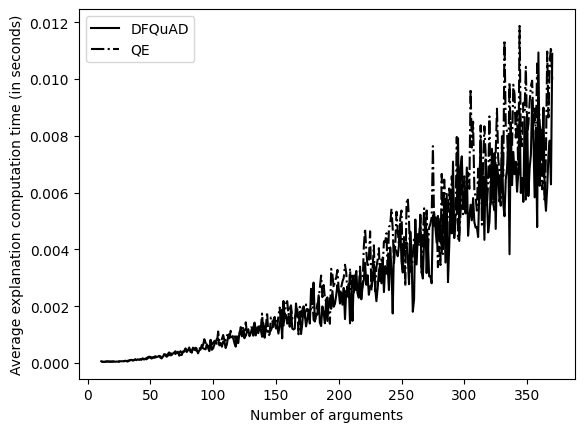

In [116]:
import matplotlib.pyplot as plt
plot = plt.plot(n_arguments_list, robustness_times_dfquad, label ='DFQuAD', color='black')
plot = plt.plot(n_arguments_list, robustness_times_qe, '-.', label ='QE', color='black')
plt.legend()
plt.ylabel('Average robustness computation time (in seconds)')
plt.xlabel('Number of arguments')

In [120]:
print(n_arguments_list[-1])

370


In [ ]:
layers = [2, 8]
for _ in range(0, 4):
    layers.append(0)
n_arguments_list = []
# DFQuAD
robustness_times_dfquad = []
pocket_times_dfquad = []
# QE
robustness_times_qe = []
pocket_times_qe = []

for i in range(2, 6):
    for j in range(1, 11):
        layers[i] = j
        n_arguments_list.append(sum(layers))
        pockets_dfquad_for_avg_times = []
        pockets_qe_for_avg_times = []
        for _ in range(0, 25):
            # DFQuAD
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "DFQuAD_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = pockets_of_consistency(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pockets_dfquad_for_avg_times.append(end_time - start_time)
            # QE
            qbafs = generate_layered_qbaf_chain(math.floor(sum(layers)/5), ['a(0, 0)', 'a(0, 1)'], layers, 0.5, "QuadraticEnergy_model", min_strength=0.3, max_strength=0.7)
            start_time = time.time()
            pockets = pockets_of_consistency(qbafs[0], qbafs, 'a(0, 0)', 'a(0, 1)')
            end_time = time.time()
            pockets_qe_for_avg_times.append(end_time - start_time)
        pocket_times_dfquad.append(mean(pockets_dfquad_for_avg_times)) 
        pocket_times_qe.append(mean(pockets_qe_for_avg_times))

In [ ]:
import matplotlib.pyplot as plt
plot = plt.plot(n_arguments_list, pocket_times_dfquad, label ='DFQuAD', color='black')
plot = plt.plot(n_arguments_list, pocket_times_qe, '-.', label ='QE', color='black')
plt.legend()
plt.ylabel('Average pocket computation time (in seconds)')
plt.xlabel('Number of arguments')

In [ ]:
print(n_arguments_list[-1])